# Interactive Result Display

This interactive notebook is being used to plot the results from performance testing on pwordcount. While the original project was to be written in C, I hope it is okay that I used a notebook here as this file is not the target project code for grading and is only used to display my findings in the report.

File: result_display.ipynb
Project: Project 2 - pWordCount
Author: Chris Hinkson @cmh02

In [1]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt

## Execution Time Analysis

This section will display some insights into the execution time with pwordcount across different metrics such as changes in the number of processes and buffer sizes.

In [3]:
# Load data from results/performance_time.csv
df_time = pd.read_csv(filepath_or_buffer='results/performance_time.csv', header=0)

# Display head to make sure data loaded correctly
df_time.head()

,Test File,Process Count,Reader Buffer Size,Counter Manager Buffer Size,Counter Buffer Size,Execution Time (seconds)
0,t00_empty.txt,1,1024,1024,1024,0.010762
1,t00_empty.txt,1,1024,1024,2048,0.007995
2,t00_empty.txt,1,1024,1024,4096,0.009040
3,t00_empty.txt,1,1024,1024,8192,0.009675
4,t00_empty.txt,1,1024,2048,1024,0.008297


In [4]:
# Make copy of dataframe where all buffer sizes are 2048
df_time_all2048buffers = df_time[
	(df_time['Reader Buffer Size'] == 2048) 
	& (df_time['Counter Manager Buffer Size'] == 2048) 
	& (df_time['Counter Buffer Size'] == 2048)
]

# Show head to ensure filtered correctly
df_time_all2048buffers.head()

,Test File,Process Count,Reader Buffer Size,Counter Manager Buffer Size,Counter Buffer Size,Execution Time (seconds)
21,t00_empty.txt,1,2048,2048,2048,0.007235
85,t00_empty.txt,2,2048,2048,2048,0.009258
149,t00_empty.txt,3,2048,2048,2048,0.010805
213,t00_empty.txt,4,2048,2048,2048,0.012091
277,t00_empty.txt,5,2048,2048,2048,0.014657


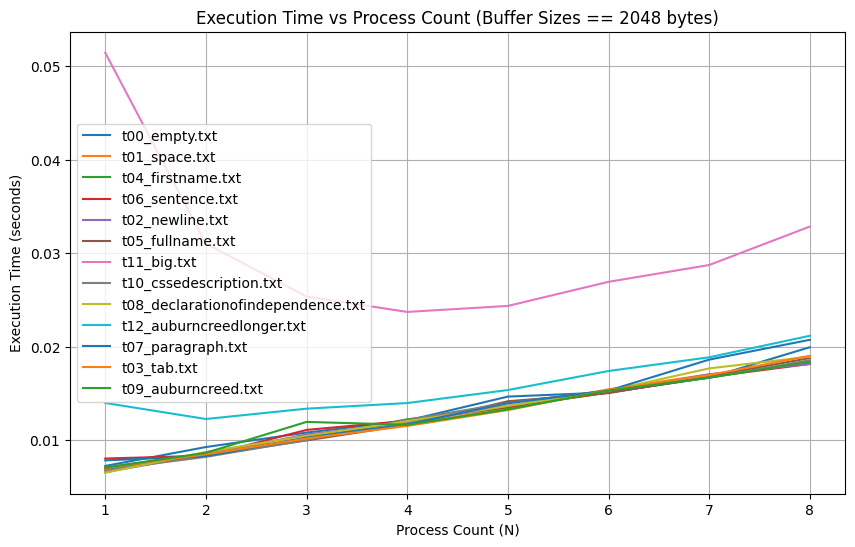

In [7]:
# Make plot figure 
plt.figure(figsize=(10, 6))
plt.title('Execution Time vs Process Count (Buffer Sizes == 2048 bytes)')
plt.xlabel('Process Count (N)')
plt.ylabel('Execution Time (seconds)')

# For each test file except 2GB, plot execution time vs process count
for test_file in df_time_all2048buffers['Test File'].unique():

	# Skip 2GB file so plot is cleaner
	if test_file == 't13_2gbfile.txt':
		continue
	
	# Get df with just this file
	testFileDf = df_time_all2048buffers[df_time_all2048buffers['Test File'] == test_file]

	# Plot line
	plt.plot(testFileDf['Process Count'], testFileDf['Execution Time (seconds)'], label=test_file)

# Show legend
plt.legend()
plt.grid()
plt.show()

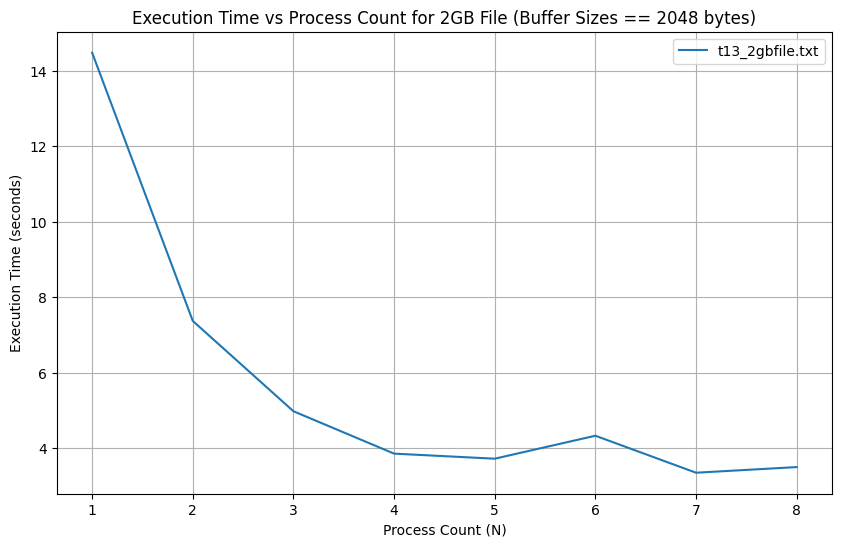

In [6]:
# Make new plot figure for 2GB file
plt.figure(figsize=(10, 6))
plt.title('Execution Time vs Process Count for 2GB File (Buffer Sizes == 2048 bytes)')
plt.xlabel('Process Count (N)')
plt.ylabel('Execution Time (seconds)')

# Get df with just 2GB file
df_time_all2048buffers_2gb = df_time_all2048buffers[df_time_all2048buffers['Test File'] == 't13_2gbfile.txt']

# Plot line for 2GB file
plt.plot(df_time_all2048buffers_2gb['Process Count'], df_time_all2048buffers_2gb['Execution Time (seconds)'], label='t13_2gbfile.txt')

# Show legend
plt.legend()
plt.grid()
plt.show()

In [11]:
# Get df where only 4 counters are used so we can look at buffer size impacts
df_time_4counters = df_time[df_time['Process Count'] == 4]

# Split into separate dfs for each buffer type, holding the other 2 buffer sizes constant at 2048
df_time_4counters_bufferReader = df_time_4counters[['Test File', 'Reader Buffer Size', 'Execution Time (seconds)']]
df_time_4counters_bufferReader = df_time_4counters[(df_time_4counters['Counter Manager Buffer Size'] == 2048) & (df_time_4counters['Counter Buffer Size'] == 2048)]
df_time_4counters_bufferCounterManager = df_time_4counters[['Test File', 'Counter Manager Buffer Size', 'Execution Time (seconds)']]
df_time_4counters_bufferCounterManager = df_time_4counters[(df_time_4counters['Reader Buffer Size'] == 2048) & (df_time_4counters['Counter Buffer Size'] == 2048)]
df_time_4counters_bufferCounter = df_time_4counters[['Test File', 'Counter Buffer Size', 'Execution Time (seconds)']]
df_time_4counters_bufferCounter = df_time_4counters[(df_time_4counters['Reader Buffer Size'] == 2048) & (df_time_4counters['Counter Manager Buffer Size'] == 2048)]


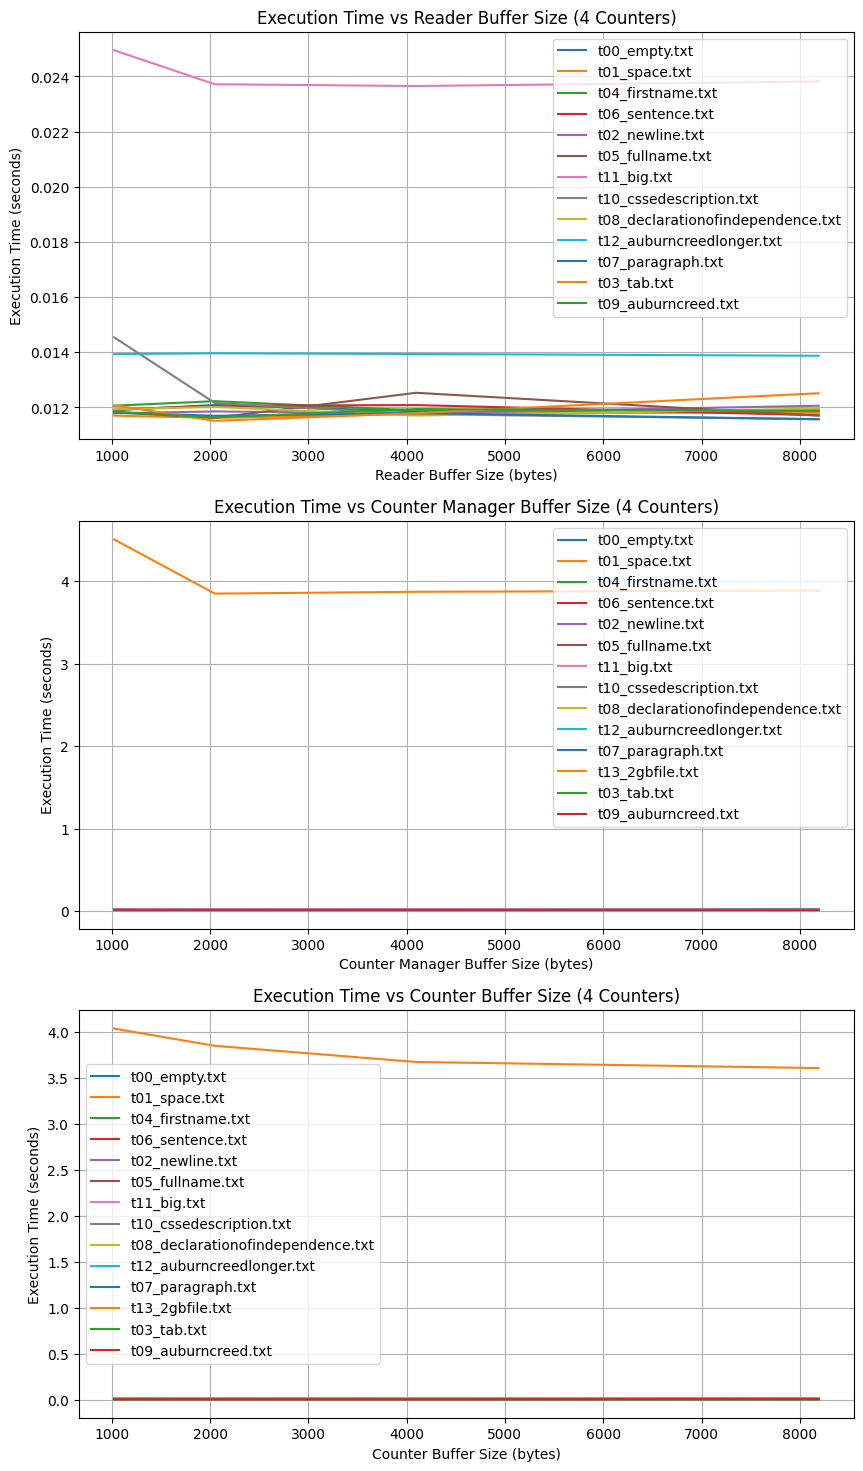

In [ ]:
# Make three plots for the buffer types
fig, axs = plt.subplots(3, 1, figsize=(10, 18))

# Plot Setup for Reader Buffer Size
axs[0].set_title('Execution Time vs Reader Buffer Size (4 Counters)')
axs[0].set_xlabel('Reader Buffer Size (bytes)')
axs[0].set_ylabel('Execution Time (seconds)')

# Plot Setup for Counter Manager Buffer Size
axs[1].set_title('Execution Time vs Counter Manager Buffer Size (4 Counters)')
axs[1].set_xlabel('Counter Manager Buffer Size (bytes)')
axs[1].set_ylabel('Execution Time (seconds)')

# Plot Setup for Counter Buffer Size
axs[2].set_title('Execution Time vs Counter Buffer Size (4 Counters)')
axs[2].set_xlabel('Counter Buffer Size (bytes)')
axs[2].set_ylabel('Execution Time (seconds)')

# Plot each test file except 2GB as a line for Reader Buffer Size
for test_file in df_time_4counters_bufferReader['Test File'].unique():

	# Skip 2GB file so plot is cleaner
	if test_file == 't13_2gbfile.txt':
		continue

	# Get df for this test file
	testFileDf = df_time_4counters_bufferReader[df_time_4counters_bufferReader['Test File'] == test_file]

	# Plot line
	axs[0].plot(testFileDf['Reader Buffer Size'], testFileDf['Execution Time (seconds)'], label=test_file)

# Plot each test file as a line for Counter Manager Buffer Size
for test_file in df_time_4counters_bufferCounterManager['Test File'].unique():
	testFileDf = df_time_4counters_bufferCounterManager[df_time_4counters_bufferCounterManager['Test File'] == test_file]
	axs[1].plot(testFileDf['Counter Manager Buffer Size'], testFileDf['Execution Time (seconds)'], label=test_file)

# Plot each test file as a line for Counter Buffer Size
for test_file in df_time_4counters_bufferCounter['Test File'].unique():
	testFileDf = df_time_4counters_bufferCounter[df_time_4counters_bufferCounter['Test File'] == test_file]
	axs[2].plot(testFileDf['Counter Buffer Size'], testFileDf['Execution Time (seconds)'], label=test_file)

# Show legends and grids
for ax in axs:
	ax.legend()
	ax.grid()

# Show plots
plt.show()

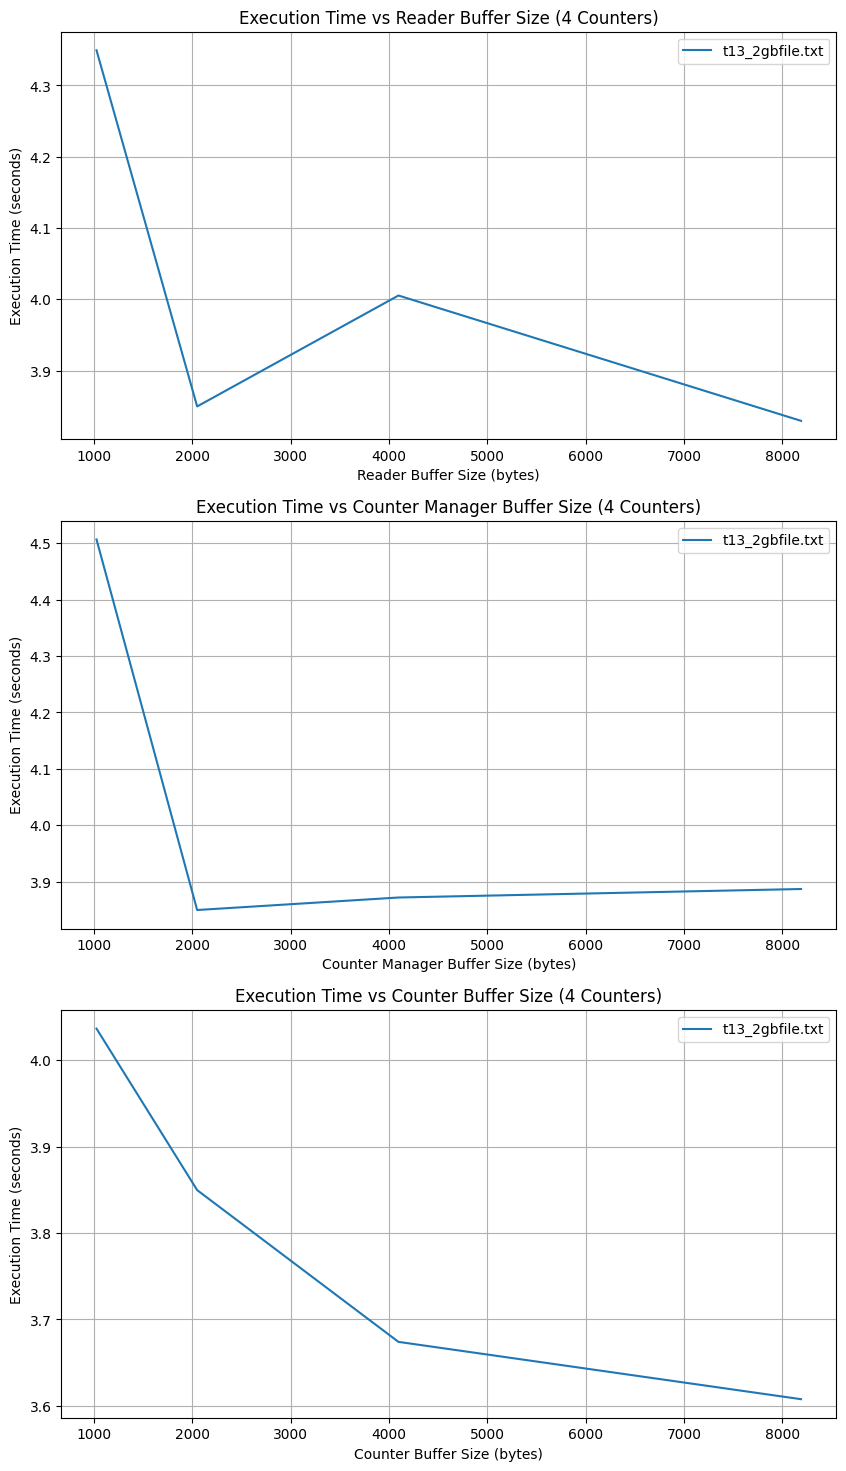

In [15]:
# Make three plots for the buffer types
fig, axs = plt.subplots(3, 1, figsize=(10, 18))

# Plot Setup for Reader Buffer Size
axs[0].set_title('Execution Time vs Reader Buffer Size (4 Counters)')
axs[0].set_xlabel('Reader Buffer Size (bytes)')
axs[0].set_ylabel('Execution Time (seconds)')

# Plot Setup for Counter Manager Buffer Size
axs[1].set_title('Execution Time vs Counter Manager Buffer Size (4 Counters)')
axs[1].set_xlabel('Counter Manager Buffer Size (bytes)')
axs[1].set_ylabel('Execution Time (seconds)')

# Plot Setup for Counter Buffer Size
axs[2].set_title('Execution Time vs Counter Buffer Size (4 Counters)')
axs[2].set_xlabel('Counter Buffer Size (bytes)')
axs[2].set_ylabel('Execution Time (seconds)')

# Plot only 2GB file as a line for Reader Buffer Size
testFileDf = df_time_4counters_bufferReader[df_time_4counters_bufferReader['Test File'] == 't13_2gbfile.txt']
axs[0].plot(testFileDf['Reader Buffer Size'], testFileDf['Execution Time (seconds)'], label='t13_2gbfile.txt')

# Plot only 2GB file as a line for Counter Manager Buffer Size
testFileDf = df_time_4counters_bufferCounterManager[df_time_4counters_bufferCounterManager['Test File'] == 't13_2gbfile.txt']
axs[1].plot(testFileDf['Counter Manager Buffer Size'], testFileDf['Execution Time (seconds)'], label='t13_2gbfile.txt')

# Plot only 2GB file as a line for Counter Buffer Size
testFileDf = df_time_4counters_bufferCounter[df_time_4counters_bufferCounter['Test File'] == 't13_2gbfile.txt']
axs[2].plot(testFileDf['Counter Buffer Size'], testFileDf['Execution Time (seconds)'], label='t13_2gbfile.txt')

# Show legends and grids
for ax in axs:
	ax.legend()
	ax.grid()

# Show plots
plt.show()

## Memory Usage Analysis

This section will display some insights into the memory usage with pwordcount across different metrics such as changes in the number of processes and buffer sizes.

In [17]:
# Load data from results/performance_time.csv
df_mem = pd.read_csv(filepath_or_buffer='results/performance_memory.csv', header=0)

# Display head to make sure data loaded correctly
df_mem.head()

,Test File,Process Count,Reader Buffer Size,Counter Manager Buffer Size,Counter Buffer Size,Memory Usage
0,t00_empty.txt,1,1024,1024,1024,1277952
1,t00_empty.txt,1,1024,1024,2048,1310720
2,t00_empty.txt,1,1024,1024,4096,1294336
3,t00_empty.txt,1,1024,1024,8192,1310720
4,t00_empty.txt,1,1024,2048,1024,1310720


In [23]:
# Convert bytes to KB for easier reading
df_mem['Memory Usage (KB)'] = df_mem['Memory Usage'] / 1024
df_mem.drop(columns=['Memory Usage'], inplace=True)

In [24]:
# Make copy of dataframe where all buffer sizes are 2048
df_mem_all2048buffers = df_mem[
	(df_mem['Reader Buffer Size'] == 2048) 
	& (df_mem['Counter Manager Buffer Size'] == 2048) 
	& (df_mem['Counter Buffer Size'] == 2048)
]

# Show head to ensure filtered correctly
df_mem_all2048buffers.head()

,Test File,Process Count,Reader Buffer Size,Counter Manager Buffer Size,Counter Buffer Size,Memory Usage (KB)
21,t00_empty.txt,1,2048,2048,2048,1312.0
85,t00_empty.txt,2,2048,2048,2048,1408.0
149,t00_empty.txt,3,2048,2048,2048,1424.0
213,t00_empty.txt,4,2048,2048,2048,1280.0
277,t00_empty.txt,5,2048,2048,2048,1280.0


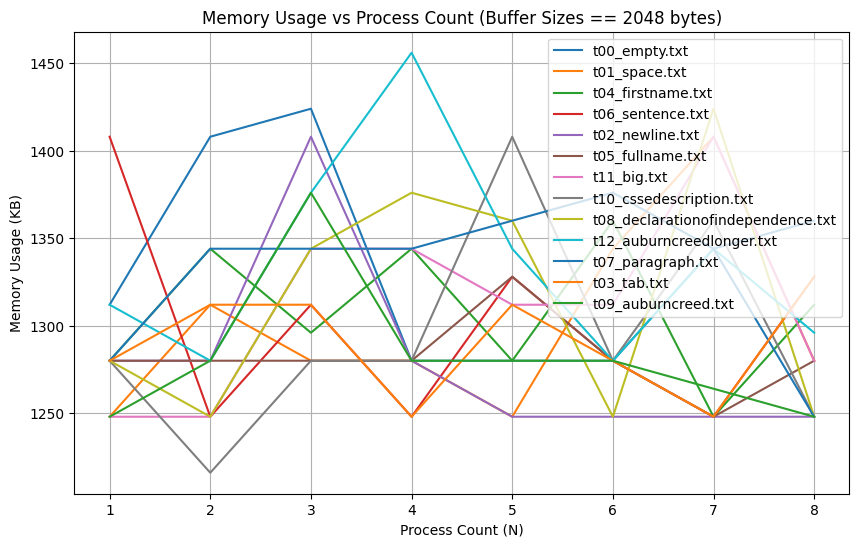

In [26]:
# Make plot figure 
plt.figure(figsize=(10, 6))
plt.title('Memory Usage vs Process Count (Buffer Sizes == 2048 bytes)')
plt.xlabel('Process Count (N)')
plt.ylabel('Memory Usage (KB)')

# For each test file except 2GB, plot memory usage vs process count
for test_file in df_mem_all2048buffers['Test File'].unique():

	# Skip 2GB file so plot is cleaner
	if test_file == 't13_2gbfile.txt':
		continue
	
	# Get df with just this file
	testFileDf = df_mem_all2048buffers[df_mem_all2048buffers['Test File'] == test_file]

	# Plot line
	plt.plot(testFileDf['Process Count'], testFileDf['Memory Usage (KB)'], label=test_file)

# Show legend
plt.legend()
plt.grid()
plt.show()

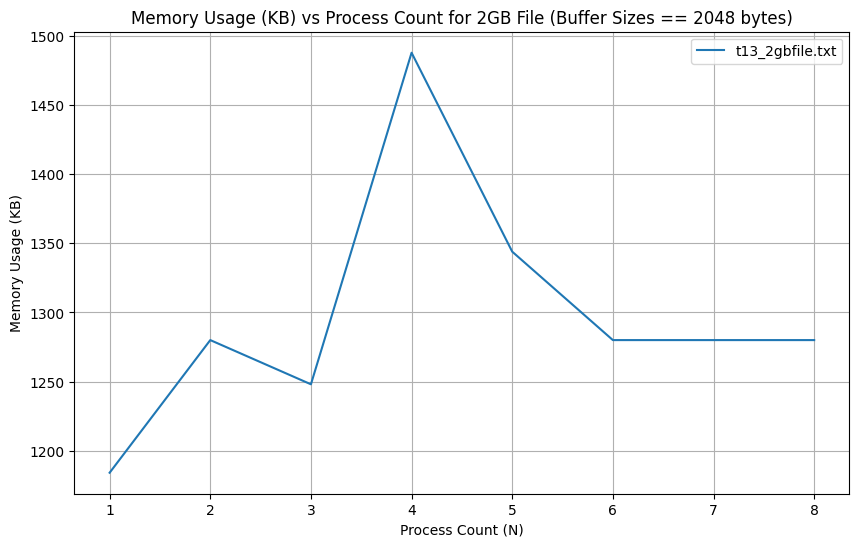

In [27]:
# Make new plot figure for 2GB file
plt.figure(figsize=(10, 6))
plt.title('Memory Usage (KB) vs Process Count for 2GB File (Buffer Sizes == 2048 bytes)')
plt.xlabel('Process Count (N)')
plt.ylabel('Memory Usage (KB)')

# Get df with just 2GB file
df_mem_all2048buffers_2gb = df_mem_all2048buffers[df_mem_all2048buffers['Test File'] == 't13_2gbfile.txt']

# Plot line for 2GB file
plt.plot(df_mem_all2048buffers_2gb['Process Count'], df_mem_all2048buffers_2gb['Memory Usage (KB)'], label='t13_2gbfile.txt')

# Show legend
plt.legend()
plt.grid()
plt.show()

In [28]:
# Get df where only 4 counters are used so we can look at buffer size impacts
df_mem_4counters = df_mem[df_mem['Process Count'] == 4]

# Split into separate dfs for each buffer type, holding the other 2 buffer sizes constant at 2048
df_mem_4counters_bufferReader = df_mem_4counters[['Test File', 'Reader Buffer Size', 'Memory Usage (KB)']]
df_mem_4counters_bufferReader = df_mem_4counters[(df_mem_4counters['Counter Manager Buffer Size'] == 2048) & (df_mem_4counters['Counter Buffer Size'] == 2048)]
df_mem_4counters_bufferCounterManager = df_mem_4counters[['Test File', 'Counter Manager Buffer Size', 'Memory Usage (KB)']]
df_mem_4counters_bufferCounterManager = df_mem_4counters[(df_mem_4counters['Reader Buffer Size'] == 2048) & (df_mem_4counters['Counter Buffer Size'] == 2048)]
df_mem_4counters_bufferCounter = df_mem_4counters[['Test File', 'Counter Buffer Size', 'Memory Usage (KB)']]
df_mem_4counters_bufferCounter = df_mem_4counters[(df_mem_4counters['Reader Buffer Size'] == 2048) & (df_mem_4counters['Counter Manager Buffer Size'] == 2048)]

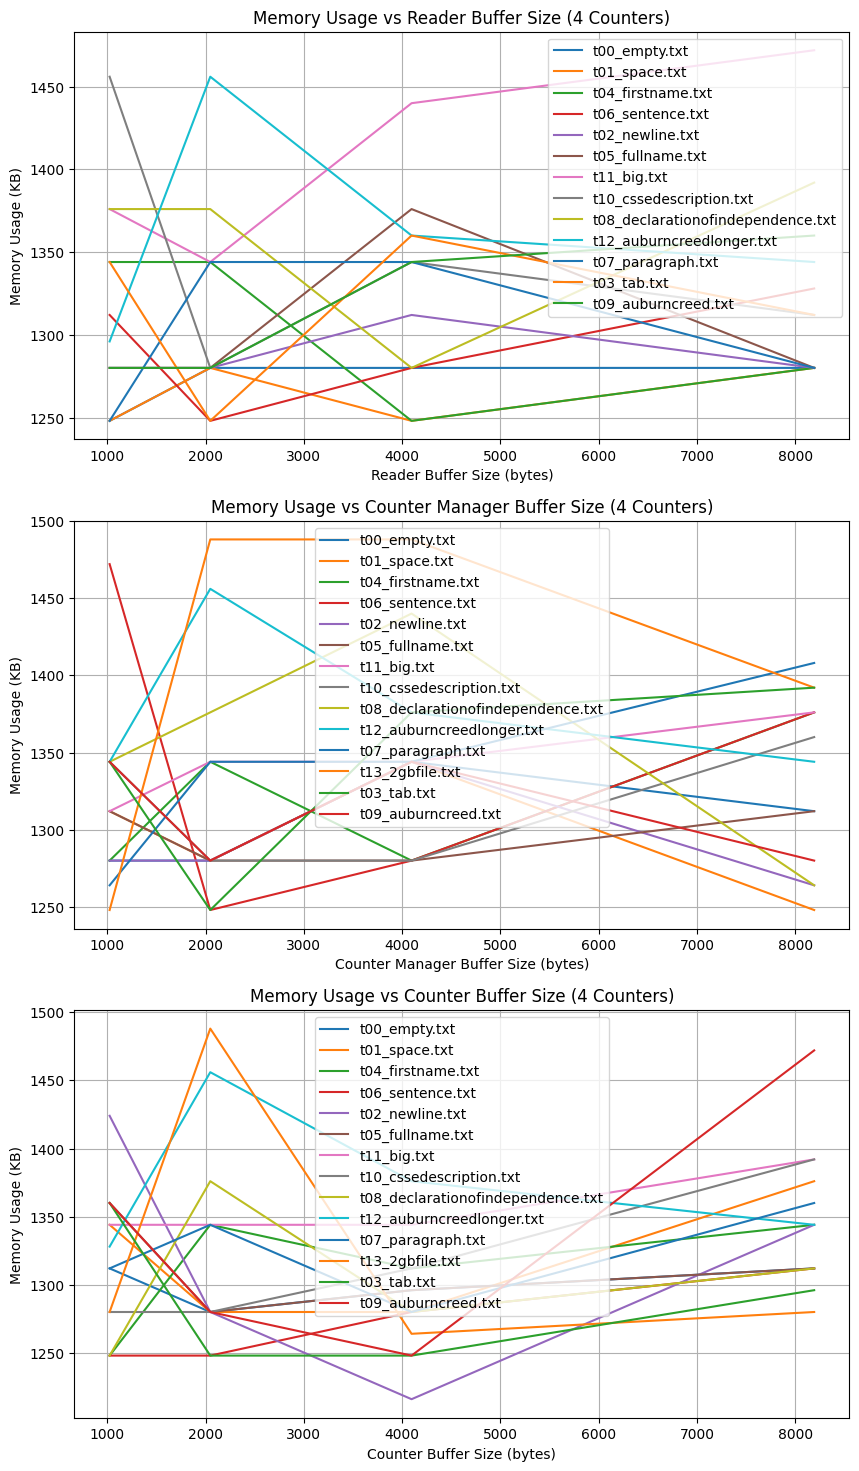

In [29]:
# Make three plots for the buffer types
fig, axs = plt.subplots(3, 1, figsize=(10, 18))

# Plot Setup for Reader Buffer Size
axs[0].set_title('Memory Usage vs Reader Buffer Size (4 Counters)')
axs[0].set_xlabel('Reader Buffer Size (bytes)')
axs[0].set_ylabel('Memory Usage (KB)')

# Plot Setup for Counter Manager Buffer Size
axs[1].set_title('Memory Usage vs Counter Manager Buffer Size (4 Counters)')
axs[1].set_xlabel('Counter Manager Buffer Size (bytes)')
axs[1].set_ylabel('Memory Usage (KB)')

# Plot Setup for Counter Buffer Size
axs[2].set_title('Memory Usage vs Counter Buffer Size (4 Counters)')
axs[2].set_xlabel('Counter Buffer Size (bytes)')
axs[2].set_ylabel('Memory Usage (KB)')

# Plot each test file except 2GB as a line for Reader Buffer Size
for test_file in df_mem_4counters_bufferReader['Test File'].unique():

	# Skip 2GB file so plot is cleaner
	if test_file == 't13_2gbfile.txt':
		continue

	# Get df for this test file
	testFileDf = df_mem_4counters_bufferReader[df_mem_4counters_bufferReader['Test File'] == test_file]

	# Plot line
	axs[0].plot(testFileDf['Reader Buffer Size'], testFileDf['Memory Usage (KB)'], label=test_file)

# Plot each test file as a line for Counter Manager Buffer Size
for test_file in df_mem_4counters_bufferCounterManager['Test File'].unique():
	testFileDf = df_mem_4counters_bufferCounterManager[df_mem_4counters_bufferCounterManager['Test File'] == test_file]
	axs[1].plot(testFileDf['Counter Manager Buffer Size'], testFileDf['Memory Usage (KB)'], label=test_file)

# Plot each test file as a line for Counter Buffer Size
for test_file in df_mem_4counters_bufferCounter['Test File'].unique():
	testFileDf = df_mem_4counters_bufferCounter[df_mem_4counters_bufferCounter['Test File'] == test_file]
	axs[2].plot(testFileDf['Counter Buffer Size'], testFileDf['Memory Usage (KB)'], label=test_file)

# Show legends and grids
for ax in axs:
	ax.legend()
	ax.grid()

# Show plots
plt.show()

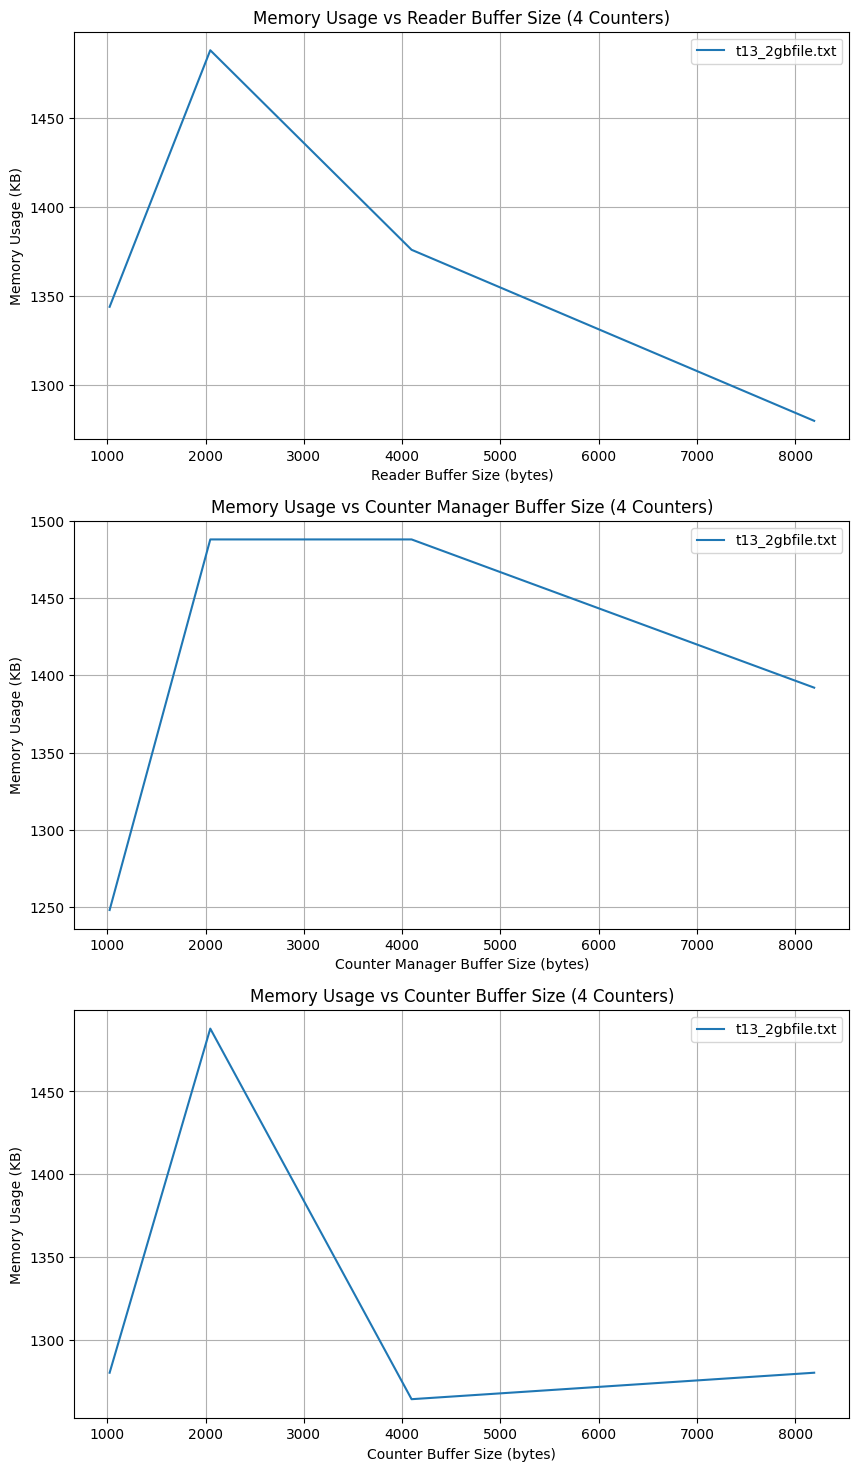

In [30]:
# Make three plots for the buffer types
fig, axs = plt.subplots(3, 1, figsize=(10, 18))

# Plot Setup for Reader Buffer Size
axs[0].set_title('Memory Usage vs Reader Buffer Size (4 Counters)')
axs[0].set_xlabel('Reader Buffer Size (bytes)')
axs[0].set_ylabel('Memory Usage (KB)')

# Plot Setup for Counter Manager Buffer Size
axs[1].set_title('Memory Usage vs Counter Manager Buffer Size (4 Counters)')
axs[1].set_xlabel('Counter Manager Buffer Size (bytes)')
axs[1].set_ylabel('Memory Usage (KB)')

# Plot Setup for Counter Buffer Size
axs[2].set_title('Memory Usage vs Counter Buffer Size (4 Counters)')
axs[2].set_xlabel('Counter Buffer Size (bytes)')
axs[2].set_ylabel('Memory Usage (KB)')

# Plot only 2GB file as a line for Reader Buffer Size
testFileDf = df_mem_4counters_bufferReader[df_mem_4counters_bufferReader['Test File'] == 't13_2gbfile.txt']
axs[0].plot(testFileDf['Reader Buffer Size'], testFileDf['Memory Usage (KB)'], label='t13_2gbfile.txt')

# Plot only 2GB file as a line for Counter Manager Buffer Size
testFileDf = df_mem_4counters_bufferCounterManager[df_mem_4counters_bufferCounterManager['Test File'] == 't13_2gbfile.txt']
axs[1].plot(testFileDf['Counter Manager Buffer Size'], testFileDf['Memory Usage (KB)'], label='t13_2gbfile.txt')

# Plot only 2GB file as a line for Counter Buffer Size
testFileDf = df_mem_4counters_bufferCounter[df_mem_4counters_bufferCounter['Test File'] == 't13_2gbfile.txt']
axs[2].plot(testFileDf['Counter Buffer Size'], testFileDf['Memory Usage (KB)'], label='t13_2gbfile.txt')

# Show legends and grids
for ax in axs:
	ax.legend()
	ax.grid()

# Show plots
plt.show()